## BulkFormer-embeddings and Feed-Forward Neural Network (FFNN)

This Jupyter notebook explains the code to extract the embeddings from BulkFormer and provides some plots to visualize the results obtained from training a FFNN that uses these embeddings as input. 


### Extract embeddings

The code starts by loading the preprocessed data into pandas dataframes, and loads the bulformer model (you need to previously clone it, we did it in the blackhole due to its size). 

It continues by aligning our genes to BulkFormer's gene order and filters out the genes that are not present in the model (mostly non-coding RNAs). 

Then it chooses which genes to pool over: it loads high_var_gene_idx.pt (indices of highly variable genes) and uses those to pick which gene embeddings to aggregate when forming a per-sample embedding. 

Finally, it runs the model and computes the embeddings, converting the input into a tensor and feeding it in batches. 

All these per-batch embeddings are stacked into a final tensor res_bulk of shape (N, D_embed). The script saves the embeddings and the original targets into bulkformer_result.pt, which is the dataset we use as input for the FFNN, that runs exactly the same as the baseline one. 

### Visualize results from FFNN using BulkFormer's embeddings

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#Set the theme for seaborn
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 25,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "figure.dpi": 300
})

In [3]:
# Path to the architecture search results CSV file
results_path = "~/DeepIsoQ/Bulkformer/ffnn_search_bulkformer/results/arch_search_results_bulkformer_stage2.csv"
# Load the results into a DataFrame
results_df = pd.read_csv(results_path)
print("Loaded architecture search results:")
print(results_df.head())


Loaded architecture search results:
                            name             hidden        act  dropout  \
0     L2_1024_1024_BF_t42_stage2       [1024, 1024]       gelu      0.1   
1  L3_1024_512_2048_BF_t8_stage2  [1024, 512, 2048]       gelu      0.2   
2      L2_256_2048_BF_t60_stage2        [256, 2048]       gelu      0.2   
3     L2_1024_1024_BF_t27_stage2       [1024, 1024]       gelu      0.0   
4      L2_512_2048_BF_t30_stage2        [512, 2048]  leakyrelu      0.1   

   batchnorm     lr momentum step_size gamma  batch_size  epochs_trained  \
0      False  0.002        -         -     -         192             200   
1       True  0.002        -         -     -         192             200   
2       True  0.002        -         -     -         128             200   
3      False  0.002        -         -     -         256              95   
4       True  0.003        -         -     -         192             200   

    val_mse  val_pearson  train_time_sec  
0  0.997192  

In [4]:
#Sort by validation MSE
df_mse = results_df.sort_values("val_mse", ascending = True)

#Sort by validation Pearson correlation
df_pearson = results_df.sort_values("val_pearson", ascending = False)


/tmp/ipykernel_1818821/2442136500.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1818821/2442136500.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


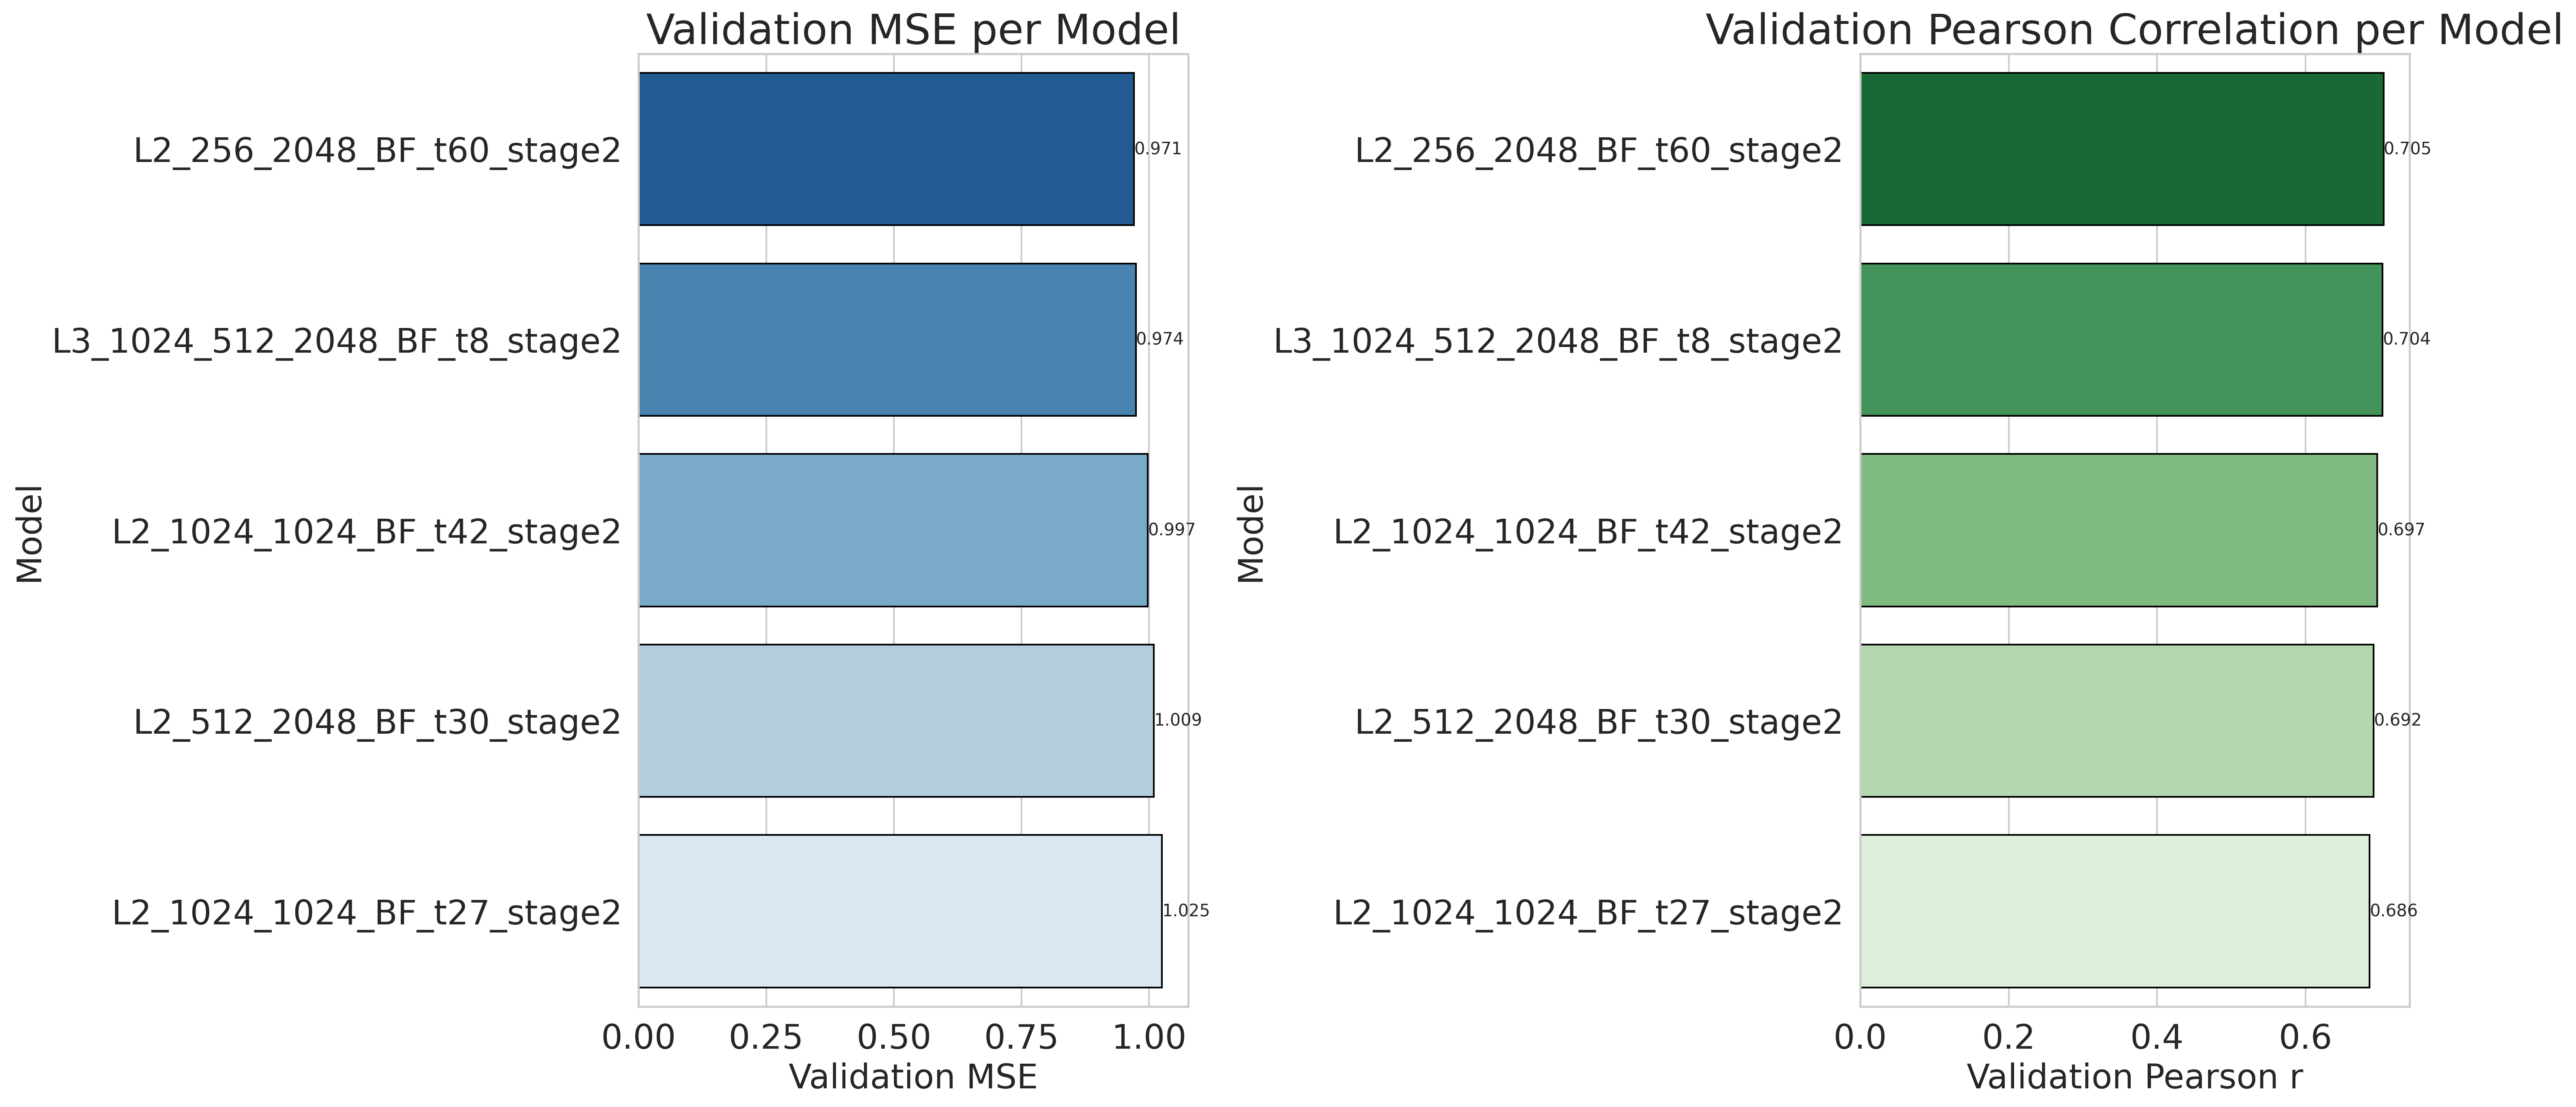

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)

# Validation MSE
sns.barplot(
    ax=axes[0],
    data=df_mse,
    y="name",
    x="val_mse",
    palette="Blues_r",
    edgecolor="black"
)
axes[0].set_title("Validation MSE per Model")
axes[0].set_xlabel("Validation MSE")
axes[0].set_ylabel("Model")
# Annotate bars with MSE values
for i, v in enumerate(df_mse["val_mse"]):
    axes[0].text(v, i, f"{v:.3f}", va="center", ha="left", fontsize=10)

# Validation Pearson Correlation
sns.barplot(
    ax=axes[1],
    data=df_pearson,
    y="name",
    x="val_pearson",
    palette="Greens_r",
    edgecolor="black"
)
axes[1].set_title("Validation Pearson Correlation per Model")
axes[1].set_xlabel("Validation Pearson r")
axes[1].set_ylabel("Model")
# Annotate bars with Pearson r values
for i, v in enumerate(df_pearson["val_pearson"]):
    axes[1].text(v, i, f"{v:.3f}", va="center", ha="left", fontsize=10)

plt.show()